In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 

from sklearn.metrics import brier_score_loss

# from sklearn.model_selection import GridSearchCV # used in the validation process to determine the optimal combination of hyperparameters; ultimately did NOT choose because we have solid TTV split

In [2]:
# BartTorvik Dataset
barttorvik = pd.read_csv("Dataset/Barttorvik Away-Neutral.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
barttorvik_features = ['TEAM','YEAR', 'TEAM NO', 'SEED', 'BADJ O', 'BADJ D', 'EFG%','EFG%D', 'FTR', 'FTRD', 'FT%', 'TOV%', 'TOV%D', 'OREB%', 'DREB%', 
'2PT%', '2PT%D', '3PT%', '3PT%D', 'BLK%', 'BLKED%', 'AST%', 'OP AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'BADJ T', 'EFF HGT', 'EXP', 'TALENT', 'PPPO', 'PPPD', 'ELITE SOS', 'WAB']
barttorvik = barttorvik[barttorvik_features]
barttorvik.head()

,TEAM,YEAR,TEAM NO,SEED,BADJ O,BADJ D,EFG%,EFG%D,FTR,FTRD,...,2PTRD,3PTRD,BADJ T,EFF HGT,EXP,TALENT,PPPO,PPPD,ELITE SOS,WAB
6,Auburn,2025,1141,1,133.1,96.3,55.0,48.6,31.1,43.0,...,67.3,32.7,67.1,81.057,2.573,34.433,1.198,1.081,60.183,9.3
15,Duke,2025,1132,1,126.3,90.8,56.9,46.5,30.4,28.6,...,62.3,37.7,65.9,82.221,0.968,80.734,1.195,0.968,46.878,6.4
16,Florida,2025,1131,1,127.0,96.2,53.6,48.6,33.6,34.0,...,61.2,38.8,70.4,82.097,1.887,28.619,1.179,1.048,52.381,7.8
21,Houston,2025,1126,1,122.6,89.4,50.2,45.7,30.1,36.2,...,56.4,43.6,61.9,79.578,2.278,75.695,1.115,0.988,54.419,7.6
80,Connecticut,2024,1067,1,128.5,97.3,56.7,48.4,30.9,33.8,...,68.0,32.0,64.7,81.572,1.709,58.255,1.202,1.056,49.513,7.8


In [3]:
# EvanMiya Dataset
evan_miya = pd.read_csv("Dataset/EvanMiya.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
evan_miya_features = ['TEAM', 'YEAR', 'TEAM NO', 'O RATE', 'D RATE','OPPONENT ADJUST', 'PACE ADJUST', 'TRUE TEMPO']
evan_miya = evan_miya[evan_miya_features]
evan_miya.head()

,TEAM,YEAR,TEAM NO,O RATE,D RATE,OPPONENT ADJUST,PACE ADJUST,TRUE TEMPO
6,Auburn,2025,1141,18.345438,12.090102,-10.808910,75.564620,69.449925
15,Duke,2025,1132,20.629884,15.188260,10.622804,28.211637,67.422555
16,Florida,2025,1131,18.648040,14.191978,99.009901,43.853550,71.319010
21,Houston,2025,1126,15.624891,18.508179,-15.419621,-3.573542,63.501250
80,Connecticut,2024,1067,19.151259,13.722032,87.919098,45.225030,66.376877


In [4]:
# KenPom Dataset
kenpom = pd.read_csv("Dataset/KenPom Barttorvik.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
# Note: O, D, T very similar to barrtorvik - essentially same metric different derived using slightly different methods
kenpom_features = ['TEAM', 'YEAR', 'TEAM NO', 'KADJ O', 'KADJ D', 'KADJ T']  
kenpom = kenpom[kenpom_features]
kenpom.head()

,TEAM,YEAR,TEAM NO,KADJ O,KADJ D,KADJ T
6,Auburn,2025,1141,128.505,93.4663,67.6684
15,Duke,2025,1132,127.999,89.8470,65.8030
16,Florida,2025,1131,127.938,92.1126,69.5912
21,Houston,2025,1126,123.269,87.8253,61.5016
80,Connecticut,2024,1067,126.608,94.3949,64.4543


In [5]:
# RPPF Dataset
rppf = pd.read_csv("Dataset/RPPF Ratings.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
rppf_features = ['TEAM', 'YEAR', 'TEAM NO', 'RADJ O', 'RADJ D', 'R PACE', 'R SOS', 'STROE', 'STRDE']
rppf = rppf[rppf_features]
rppf.head()

,TEAM,YEAR,TEAM NO,RADJ O,RADJ D,R PACE,R SOS,STROE,STRDE
6,Auburn,2025,1141,129.1,93.2,67.6,0.8049,113.57,82.51
15,Duke,2025,1132,128.9,89.7,65.8,0.7273,109.01,80.16
16,Florida,2025,1131,130.0,92.5,69.7,0.7543,117.14,78.92
21,Houston,2025,1126,123.2,87.3,61.5,0.7660,94.77,82.45
80,Connecticut,2024,1067,127.1,93.8,64.5,0.7260,106.18,87.29


In [6]:
# Shooting Splits Dataset
shooting_splits = pd.read_csv("Dataset/Shooting Splits.csv").sort_values(by = ['YEAR'], ascending = [False])
shooting_splits_features = ['TEAM', 'YEAR', 'TEAM NO', 'CLOSE TWOS FG%', 'CLOSE TWOS SHARE', 'CLOSE TWOS FG%D', 
'CLOSE TWOS D SHARE', 'FARTHER TWOS FG%', 'FARTHER TWOS SHARE', 'FARTHER TWOS FG%D', 'FARTHER TWOS D SHARE', 'THREES FG%',
'THREES SHARE', 'THREES FG%D', 'THREES D SHARE']
shooting_splits = shooting_splits[shooting_splits_features]
shooting_splits.head()

,TEAM,YEAR,TEAM NO,CLOSE TWOS FG%,CLOSE TWOS SHARE,CLOSE TWOS FG%D,CLOSE TWOS D SHARE,FARTHER TWOS FG%,FARTHER TWOS SHARE,FARTHER TWOS FG%D,FARTHER TWOS D SHARE,THREES FG%,THREES SHARE,THREES FG%D,THREES D SHARE
0,Akron,2025,1147,61.8,38.2,55.3,41.7,42.0,16.5,41.0,20.3,36.6,45.4,31.9,38.0
1,Alabama,2025,1146,62.4,42.0,56.8,34.5,50.0,11.8,39.6,30.4,35.0,46.2,30.8,35.1
2,Alabama St.,2025,1145,53.1,36.6,57.7,39.0,31.5,20.5,37.4,21.6,32.9,42.9,33.4,39.5
3,American,2025,1144,58.5,33.8,62.2,40.2,39.4,21.4,37.9,24.2,35.1,44.8,33.6,35.7
4,Arizona,2025,1143,65.9,39.8,55.8,29.5,38.4,25.6,38.5,28.6,32.4,34.6,33.6,41.9


In [7]:
# Creating one df based on our merged team features
df = barttorvik.merge(evan_miya, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.merge(kenpom, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.merge(rppf, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.merge(shooting_splits, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.drop(columns = ['TEAM', 'YEAR'])
mm_team_features = df.groupby(['TEAM NO']).mean() # TEAM NO = key; represents TEAM + YEAR

In [8]:
# Data of all teams from 2013-25
mm_team_features 

,SEED,BADJ O,BADJ D,EFG%,EFG%D,FTR,FTRD,FT%,TOV%,TOV%D,...,CLOSE TWOS FG%D,CLOSE TWOS D SHARE,FARTHER TWOS FG%,FARTHER TWOS SHARE,FARTHER TWOS FG%D,FARTHER TWOS D SHARE,THREES FG%,THREES SHARE,THREES FG%D,THREES D SHARE
TEAM NO,,,,,,,,,,,,,,,,,,,,,
332,5.0,106.3,87.9,45.8,45.2,34.2,30.5,62.7,16.5,16.4,...,53.7,33.3,37.0,29.9,34.2,41.8,33.0,40.1,28.9,24.9
333,9.0,105.9,91.8,48.8,46.4,32.9,46.8,70.8,20.3,19.2,...,53.8,27.8,34.6,31.3,35.6,35.7,33.9,35.3,32.2,36.6
334,16.0,98.8,100.9,48.1,48.9,34.8,41.3,66.3,23.5,20.6,...,60.9,30.6,36.2,30.4,36.8,38.0,32.7,36.2,32.4,31.3
335,9.0,106.2,91.5,47.4,47.4,47.6,41.8,73.7,23.7,21.4,...,51.8,30.5,35.2,29.8,34.2,33.5,33.2,35.3,37.2,36.0
336,5.0,114.8,96.8,52.0,51.7,31.8,43.7,68.2,18.6,25.0,...,61.1,40.4,40.3,30.7,33.6,26.6,35.1,35.7,32.9,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,4.0,120.7,96.3,50.1,49.4,33.9,32.5,80.4,17.0,15.6,...,55.8,29.5,38.4,25.6,38.5,28.6,32.4,34.6,33.6,41.9
1144,16.0,102.0,110.7,50.2,55.1,27.5,39.0,76.8,16.9,16.2,...,62.2,40.2,39.4,21.4,37.9,24.2,35.1,44.8,33.6,35.7
1145,16.0,100.5,107.7,45.6,50.5,28.4,37.4,68.8,14.2,17.9,...,57.7,39.0,31.5,20.5,37.4,21.6,32.9,42.9,33.4,39.5


In [9]:
# dataset of prior March Madness matchups - basic info
doubled_matchups = pd.read_csv("Dataset/Tournament Matchups.csv") # one game spans two rows --> want to have one row per game
doubled_matchups

,YEAR,BY YEAR NO,TEAM NO,TEAM,SEED,ROUND,CURRENT ROUND,SCORE
0,2025,2140,1141,Auburn,1,4,64,83
1,2025,2139,1145,Alabama St.,16,64,64,63
2,2025,2138,1119,Louisville,8,64,64,75
3,2025,2137,1134,Creighton,9,32,64,89
4,2025,2136,1114,Michigan,5,16,64,68
...,...,...,...,...,...,...,...,...
2135,2008,5,43,Kansas,1,1,4,84
2136,2008,4,37,Memphis,1,2,4,78
2137,2008,3,13,UCLA,1,4,4,63
2138,2008,2,43,Kansas,1,1,2,75


In [10]:
# updated to reflect the train/test dataset years
doubled_matchups = doubled_matchups[doubled_matchups.YEAR >= 2013] 

# only include the columns relevant to a binary (1/0) victory prediction
doubled_matchups_features = ['YEAR', 'TEAM NO', 'TEAM', 'SEED', 'SCORE']
doubled_matchups = doubled_matchups[doubled_matchups_features]

# Create a Game ID we can merge matchups on
doubled_matchups['GAME ID'] = doubled_matchups.index//2
doubled_matchups

,YEAR,TEAM NO,TEAM,SEED,SCORE,GAME ID
0,2025,1141,Auburn,1,83,0
1,2025,1145,Alabama St.,16,63,0
2,2025,1119,Louisville,8,75,1
3,2025,1134,Creighton,9,89,1
4,2025,1114,Michigan,5,68,2
...,...,...,...,...,...,...
1505,2013,333,Wichita St.,9,68,752
1506,2013,366,Michigan,4,61,753
1507,2013,341,Syracuse,4,56,753
1508,2013,370,Louisville,1,82,754


In [11]:
# Series of transformations that change 2 adjacent rows/matchup --> 1 row/matchup
matchups = doubled_matchups.merge(doubled_matchups, how = 'inner', on = 'GAME ID')
matchups = matchups[matchups['TEAM_x'] != matchups['TEAM_y']]
matchups = matchups.reset_index()
matchups = matchups.drop(columns = ['index'])
matchups = matchups[matchups.index % 2 == 0]
matchups = matchups.reset_index()
matchups = matchups.drop(columns = ['index'])

# Data Cleaning: Having our data be in order --> Better Seeded Team + NO,  Worse Seeded Team + NO
matchups['Better_Seeded_Team'] = np.where(
    matchups['SEED_x'] <= matchups['SEED_y'], 
    matchups['TEAM_x'],
    matchups['TEAM_y']
)

matchups['BST_NO'] = np.where(
    matchups['SEED_x'] <= matchups['SEED_y'],
    matchups['TEAM NO_x'],
    matchups['TEAM NO_y']
)

matchups['Worse_Seeded_Team'] = np.where(
    matchups['SEED_x'] > matchups['SEED_y'],
    matchups['TEAM_x'],
    matchups['TEAM_y']
)

matchups['WST_NO'] = np.where(
    matchups['SEED_x'] > matchups['SEED_y'],
    matchups['TEAM NO_x'],
    matchups['TEAM NO_y']
)

# Label that will be used in the train-test process
matchups['BST_Won'] = ((matchups.SEED_x <= matchups.SEED_y) & (matchups.SCORE_x > matchups.SCORE_y)).astype(int) # if the team with the lower seed (better) has a higher score

# Data Cleaning: removing redundant/useless information:
matchups = matchups.drop(columns = ['TEAM NO_x', 'TEAM_x', 'SEED_x', 'SCORE_x', 'YEAR_y', 'TEAM NO_y', 'TEAM_y',	'SEED_y', 'SCORE_y']) 
matchups = matchups.rename(columns = {'YEAR_x': 'YEAR'}) # only one year
matchups

,YEAR,GAME ID,Better_Seeded_Team,BST_NO,Worse_Seeded_Team,WST_NO,BST_Won
0,2025,0,Auburn,1141,Alabama St.,1145,1
1,2025,1,Louisville,1119,Creighton,1134,0
2,2025,2,Michigan,1114,UC San Diego,1089,1
3,2025,3,Texas A&M,1092,Yale,1080,1
4,2025,4,Mississippi,1112,North Carolina,1104,1
...,...,...,...,...,...,...,...
750,2013,750,Florida,385,Michigan,366,0
751,2013,751,Marquette,369,Syracuse,341,0
752,2013,752,Louisville,370,Wichita St.,333,1
753,2013,753,Michigan,366,Syracuse,341,1


In [12]:
years = matchups['YEAR']
years

0      2025
1      2025
2      2025
3      2025
4      2025
       ... 
750    2013
751    2013
752    2013
753    2013
754    2013
Name: YEAR, Length: 755, dtype: int64

In [13]:
train_WL = matchups['BST_Won']
train_WL

0      1
1      0
2      1
3      1
4      1
      ..
750    0
751    0
752    1
753    1
754    1
Name: BST_Won, Length: 755, dtype: int64

In [14]:
mm_team_features.columns

Index(['SEED', 'BADJ O', 'BADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'FT%',
       'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D',
       'BLK%', 'BLKED%', 'AST%', 'OP AST%', '2PTR', '3PTR', '2PTRD', '3PTRD',
       'BADJ T', 'EFF HGT', 'EXP', 'TALENT', 'PPPO', 'PPPD', 'ELITE SOS',
       'WAB', 'O RATE', 'D RATE', 'OPPONENT ADJUST', 'PACE ADJUST',
       'TRUE TEMPO', 'KADJ O', 'KADJ D', 'KADJ T', 'RADJ O', 'RADJ D',
       'R PACE', 'R SOS', 'STROE', 'STRDE', 'CLOSE TWOS FG%',
       'CLOSE TWOS SHARE', 'CLOSE TWOS FG%D', 'CLOSE TWOS D SHARE',
       'FARTHER TWOS FG%', 'FARTHER TWOS SHARE', 'FARTHER TWOS FG%D',
       'FARTHER TWOS D SHARE', 'THREES FG%', 'THREES SHARE', 'THREES FG%D',
       'THREES D SHARE'],
      dtype='object')

<b>Creating the matchup feature difference vector:</b>

In [15]:
differences = []

for _, team in matchups.iterrows():
    better_seeded_team_number = team['BST_NO']
    worse_seeded_team_number = team['WST_NO']

    # Calculate the difference in features
    better_seeded_team_stats = mm_team_features.loc[better_seeded_team_number]
    worse_seeded_team_stats = mm_team_features.loc[worse_seeded_team_number]

    # note: no need to flip signs --> model learns on its own
    diff_feature = better_seeded_team_stats - worse_seeded_team_stats # + means advantage for better seeded team; - means advantage for lower seeded team
    differences.append(diff_feature.to_list())

In [16]:
differences = np.array(differences)
differences

array([[-15. ,  32.6, -11.4, ...,  -2.3,  -4.2,  -4.7],
       [ -1. ,   8.5,  -2.7, ...,  -0.9,   1. ,   4.5],
       [ -7. ,   2.7,  -2.9, ...,  -7.1,  -1.8,  -5.4],
       ...,
       [ -8. ,   3.7, -10.8, ...,  -5.3,  -0.4,  -3.3],
       [  0. ,   4.2,   1.3, ...,   3.7,   4.3,  -6.8],
       [ -3. , -10.1, -15.2, ...,  -4.1,  -0.9,  -0.2]], shape=(755, 58))

In [17]:
diff_cols = [x + "_DIFF" for x in mm_team_features.columns.to_list()]
differences_df = pd.DataFrame(differences, columns = diff_cols)
differences_df.insert(loc = 0, column = "YEAR", value = years)
differences_df['BST_Won'] = train_WL
differences_df

,YEAR,SEED_DIFF,BADJ O_DIFF,BADJ D_DIFF,EFG%_DIFF,EFG%D_DIFF,FTR_DIFF,FTRD_DIFF,FT%_DIFF,TOV%_DIFF,...,CLOSE TWOS D SHARE_DIFF,FARTHER TWOS FG%_DIFF,FARTHER TWOS SHARE_DIFF,FARTHER TWOS FG%D_DIFF,FARTHER TWOS D SHARE_DIFF,THREES FG%_DIFF,THREES SHARE_DIFF,THREES FG%D_DIFF,THREES D SHARE_DIFF,BST_Won
0,2025,-15.0,32.6,-11.4,9.4,-1.9,2.7,5.6,4.8,-0.6,...,2.5,13.4,1.7,-3.6,2.2,3.9,-2.3,-4.2,-4.7,1
1,2025,-1.0,8.5,-2.7,3.4,0.3,0.0,9.9,0.7,-1.1,...,-0.6,-0.9,1.6,-1.4,-3.9,-0.9,-0.9,1.0,4.5,0
2,2025,-7.0,2.7,-2.9,-3.4,-1.8,-3.3,3.0,2.2,5.6,...,-5.8,4.7,1.3,2.5,11.3,-3.1,-7.1,-1.8,-5.4,1
3,2025,-9.0,-1.3,-13.2,-9.0,0.3,4.9,3.1,-3.7,3.8,...,-1.1,-13.7,-2.3,-1.7,2.2,-7.4,5.6,-0.3,-1.0,1
4,2025,-5.0,0.9,-3.7,-2.8,1.8,-0.1,11.8,1.6,-3.9,...,0.1,-0.5,8.4,-1.4,-6.0,-1.2,3.2,-0.8,6.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,2013,-1.0,-5.8,-7.6,1.8,-4.8,-3.6,4.3,-6.9,2.0,...,6.8,0.0,-8.9,-10.3,-6.2,-0.1,5.4,-1.7,-0.6,0
751,2013,-1.0,-5.2,-1.4,1.8,-1.1,-1.2,-12.6,3.2,3.9,...,3.0,5.4,-1.1,1.6,1.4,-3.8,-3.5,3.9,-4.4,0
752,2013,-8.0,3.7,-10.8,-1.2,-2.9,9.8,-8.9,1.6,-0.5,...,3.5,-1.6,-1.0,-2.7,-0.3,-0.5,-5.3,-0.4,-3.3,1
753,2013,0.0,4.2,1.3,5.8,3.1,-4.6,-17.9,6.1,-2.9,...,-5.7,6.3,1.0,10.5,12.5,4.5,3.7,4.3,-6.8,1


#### Splitting up our data into different years for the pre-2026 practice evaluation process; meant to find valid hp + avoid overfitting

In [18]:
# across all - Train-Test-Validation splits
train_differences_df = differences_df[(differences_df['YEAR'] >= 2013) & (differences_df['YEAR'] <= 2021)] 
validation_differences_df = differences_df[(differences_df['YEAR'] >= 2022) & (differences_df['YEAR'] <= 2023)] 
test_differences_df = differences_df[(differences_df['YEAR'] >= 2024) & (differences_df['YEAR'] <= 2025)] 

### Model 1: Logistic Regression + StandardScaling

In [19]:
"""Train"""
scaler = StandardScaler()

X_train = train_differences_df[diff_cols]
y_train = train_differences_df['BST_Won']

X_train_scaled = scaler.fit_transform(X_train)

# Variables used to find the best C value on the Validation set
c_range =  [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1]
validation_C_scores = {}
lowest_c_val = None

# Find the best hyperparameter for LogisticRegression (on validation data)
for c in c_range:
    model = LogisticRegression(C = c, max_iter = 1000)
    model.fit(X_train_scaled, y_train)

    """Validate"""
    X_val = validation_differences_df[diff_cols]
    y_val = validation_differences_df['BST_Won'] # ground truth
    
    X_val_scaled = scaler.transform(X_val) # Not training again: avoiding data-leakage
    
    validation_prob = model.predict_proba(X_val_scaled)[:, 1] # derive the probability that the better seeded team wins
    validation_brier = brier_score_loss(y_val, validation_prob)
    rounded_validation_brier = round(validation_brier, 4)
    
    # print(f"C = {c}: VBS = {rounded_validation_brier}") # VBS = Validation Brier Score
    validation_C_scores[c] = rounded_validation_brier

# Derive lowest Brier Score + hps
lowest_c_val = float(pd.Series(validation_C_scores).idxmin())
    
print(f"Best Validation Brier Score (LR) = {validation_C_scores[lowest_c_val]} with a C of {lowest_c_val}")

Best Validation Brier Score (LR) = 0.2486 with a C of 0.05


In [20]:
"""
Test - quality control check: need to ensure a valid Brier score here before actually testing
- want a model that does great on validation AND generalizes (reasonably well)
"""

# Refit with new train parameters
test_model = LogisticRegression(C = lowest_c_val, max_iter = 1000)
test_model.fit(X_train_scaled, y_train)

X_test = test_differences_df[diff_cols]
y_test = test_differences_df['BST_Won'] # ground truth

X_test_scaled = scaler.transform(X_test) # Not training again: avoiding data-leakage

test_prob = test_model.predict_proba(X_test_scaled)[:, 1] # derive the probability that the better seeded team wins
test_brier = brier_score_loss(y_test, test_prob)

print("Test Brier Score:", round(test_brier, 4))

test_prob_binary = np.round(test_prob)
test_correct = np.sum(test_prob_binary == y_test)

print(f"Games Predicted Correctly: {round(test_correct/len(test_prob_binary), 4)} on {len(test_prob_binary)} games")

Test Brier Score: 0.2021
Games Predicted Correctly: 0.6508 on 126 games


We see that in our LogisticRegression model, we have a Brier Score of 0.2021, with our chosen C of 0.05 from validation.

### Model 2: RandomForestClassifier

In [21]:
"""Train""" 
X_train = train_differences_df[diff_cols]
y_train = train_differences_df['BST_Won']


# Hyperparameter grid search variables:
grid_dict = {
    'n_estimators': [100, 200, 500],
    'max_depth': [2, 4, 6, 8, None],
    'min_samples_leaf': [1, 2, 5]
} 

score_params = {}

# Find the best hyperparameters for RandomForestClassifier (on validation data)
for n in grid_dict['n_estimators']:
    for d in grid_dict['max_depth']:
        for msl in grid_dict['min_samples_leaf']:
            classifier = RandomForestClassifier(random_state = 42, n_estimators = n, max_depth = d, min_samples_leaf = msl)
            classifier.fit(X_train, y_train)
        
            """Validate"""
            X_val = validation_differences_df[diff_cols]
            y_val = validation_differences_df['BST_Won'] # ground truth
               
            validation_prob = classifier.predict_proba(X_val)[:, 1] # derive the probability that the better seeded team wins
            validation_brier = brier_score_loss(y_val, validation_prob)
            rounded_validation_brier = round(validation_brier, 4)

            score_params[(n, d, msl)] = rounded_validation_brier
            # print(f"n_estimators = {n}, max_depth = {d}, min_sample_leaf = {msl}: VBS = {rounded_validation_brier}") # VBS = Validation Brier Score

# Derive lowest Brier Score + hps
lowest_hps_rf = pd.Series(score_params).idxmin()
lowest_hp_score_rf = pd.Series(score_params).min()

lowest_n_estimators_rf = lowest_hps_rf[0]
lowest_max_depth_rf = lowest_hps_rf[1]
lowest_min_samples_leaf_rf = lowest_hps_rf[2]
            
print(f"Best Validation Brier Score (RF) = {lowest_hp_score_rf} with hyperparameters of {lowest_hps_rf} of form (n_estimators, max_depth, min_samples_leaf)")

Best Validation Brier Score (RF) = 0.2044 with hyperparameters of (np.int64(100), np.int64(4), np.int64(1)) of form (n_estimators, max_depth, min_samples_leaf)


In [22]:
"""Test"""
# Refit with new train parameters
test_classifier = RandomForestClassifier(random_state=42, n_estimators = lowest_n_estimators_rf, max_depth = lowest_max_depth_rf, min_samples_leaf = lowest_min_samples_leaf_rf)
test_classifier.fit(X_train, y_train)

X_test = test_differences_df[diff_cols]
y_test = test_differences_df['BST_Won'] # ground truth

test_prob = test_classifier.predict_proba(X_test)[:, 1] # derive the probability that the better seeded team wins
test_brier = brier_score_loss(y_test, test_prob)

print("Test Brier Score:", round(test_brier, 4))

test_prob_binary = np.round(test_prob)
test_correct = np.sum(test_prob_binary == y_test)

print(f"Games Predicted Correctly: {round(test_correct/len(test_prob_binary), 4)} on {len(test_prob_binary)} games")

Test Brier Score: 0.1922
Games Predicted Correctly: 0.6825 on 126 games


Text(0.5, 0, 'Features')

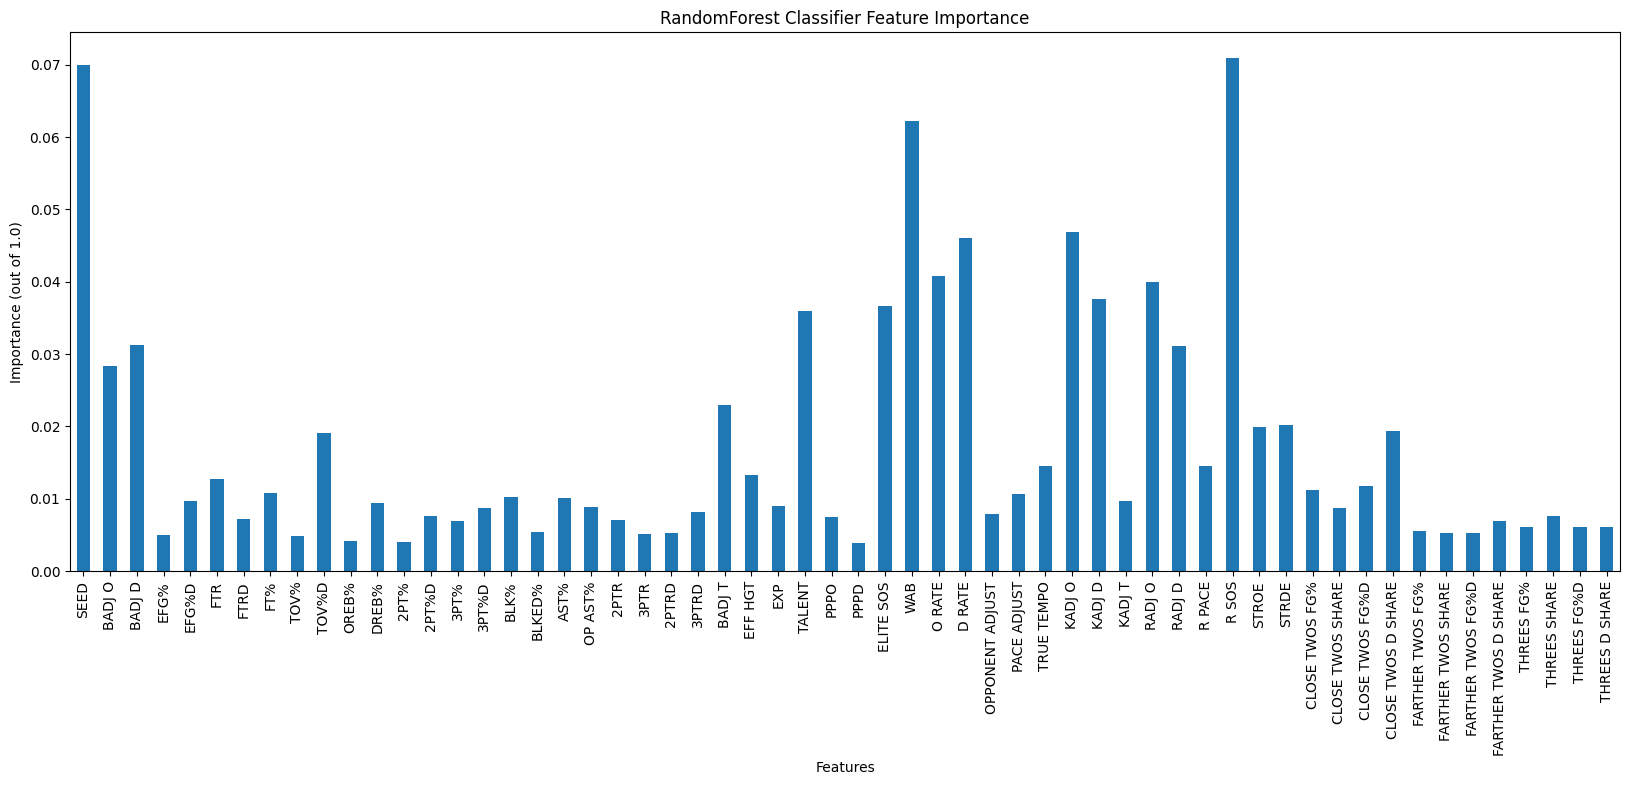

In [23]:
# Visualize feature importance
feature_importance = pd.Series(test_classifier.feature_importances_, index = mm_team_features.columns).plot.bar(figsize = (20, 7))
feature_importance.set_title('RandomForest Classifier Feature Importance')
feature_importance.set_ylabel('Importance (out of 1.0)')
feature_importance.set_xlabel('Features')

We see that in our RandomForest model, we have a Brier Score of 0.1922, with our chosen hyperparameters (n_estimators, max_depth, min_samples_leaf) of (100, 4, 1) from validation.

### Model 3: XGBoost Classifier

In [24]:
"""Train""" 
X_train = train_differences_df[diff_cols]
y_train = train_differences_df['BST_Won']


# Hyperparameter grid search variables:
grid_dict = {
    'n_estimators': [100, 200, 500],
    'max_depth': [2, 4, 6],
    'learning_rate': [0.01, 0.025, 0.05, 0.075, 0.1],
    'subsample' : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
} 

score_params = {}

# Find the best hyperparameters for XGBoost (on validation data)
for n in grid_dict['n_estimators']:
    for d in grid_dict['max_depth']:
        for r in grid_dict['learning_rate']:
            for s in grid_dict['subsample']:
                for cs in grid_dict['colsample_bytree']:
                    classifier = XGBClassifier(random_state = 42, n_estimators = n, max_depth = d, learning_rate = r, subsample = s, colsample_bytree = cs)
                    classifier.fit(X_train, y_train)
                
                    """Validate"""
                    X_val = validation_differences_df[diff_cols]
                    y_val = validation_differences_df['BST_Won'] # ground truth
                       
                    validation_prob = classifier.predict_proba(X_val)[:, 1] # derive the probability that the better seeded team wins
                    validation_brier = brier_score_loss(y_val, validation_prob)
                    rounded_validation_brier = round(validation_brier, 4)
        
                    score_params[(n, d, r, s, cs)] = rounded_validation_brier

# Derive lowest Brier Score + hps
lowest_hps = pd.Series(score_params).idxmin()
lowest_hp_score = pd.Series(score_params).min()

lowest_n_estimators = lowest_hps[0]
lowest_max_depth = lowest_hps[1]
lowest_learning_rate = lowest_hps[2]
lowest_subsample = lowest_hps[3]
lowest_colsample_bytree = lowest_hps[4]
            
print(f"Best Validation Brier Score (XGB) = {lowest_hp_score} with hyperparameters of {lowest_hps} of form (n_estimators, max_depth, learning_rate, subsample, colsample_bytree)")

Best Validation Brier Score (XGB) = 0.207 with hyperparameters of (np.int64(100), np.int64(2), np.float64(0.025), np.float64(1.0), np.float64(1.0)) of form (n_estimators, max_depth, learning_rate, subsample, colsample_bytree)


In [25]:
"""Test"""
# Refit with new train parameters
test_classifier = XGBClassifier(random_state=42, n_estimators = lowest_n_estimators, max_depth = lowest_max_depth, learning_rate = lowest_learning_rate, subsample = lowest_subsample, colsample_bytree = lowest_colsample_bytree)
test_classifier.fit(X_train, y_train)

X_test = test_differences_df[diff_cols]
y_test = test_differences_df['BST_Won'] # ground truth

test_prob = test_classifier.predict_proba(X_test)[:, 1] # derive the probability that the better seeded team wins
test_brier = brier_score_loss(y_test, test_prob)

print("Test Brier Score:", round(test_brier, 4))

test_prob_binary = np.round(test_prob)
test_correct = np.sum(test_prob_binary == y_test)

print(f"Games Predicted Correctly: {round(test_correct/len(test_prob_binary), 4)} on {len(test_prob_binary)} games")

Test Brier Score: 0.1966
Games Predicted Correctly: 0.6825 on 126 games


Text(0.5, 0, 'Features')

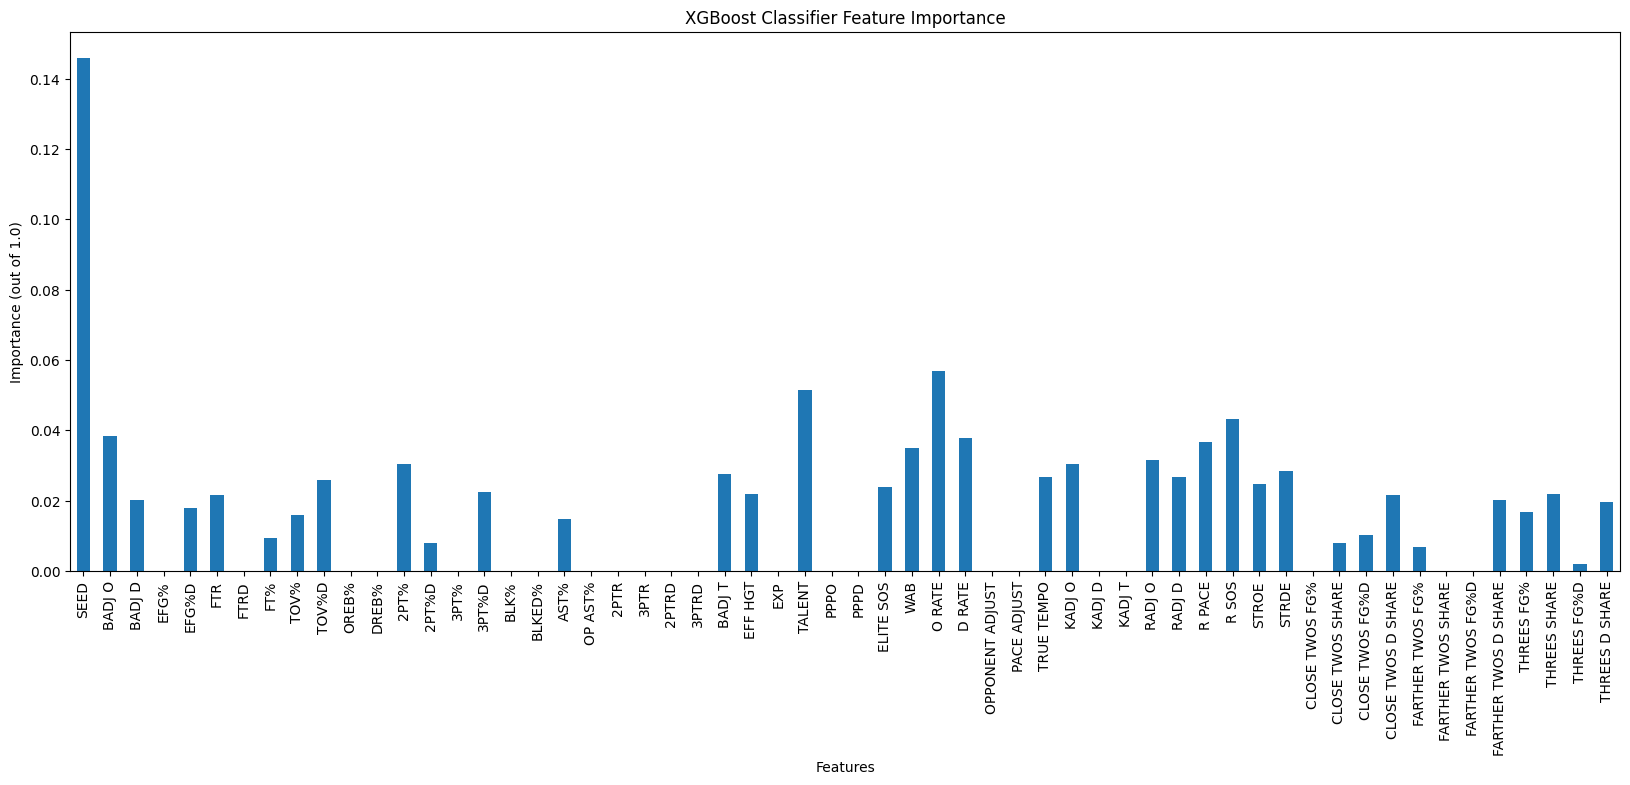

In [26]:
# Visualize feature importance
feature_importance = pd.Series(test_classifier.feature_importances_, index = mm_team_features.columns).plot.bar(figsize = (20, 7))
feature_importance.set_title('XGBoost Classifier Feature Importance')
feature_importance.set_ylabel('Importance (out of 1.0)')
feature_importance.set_xlabel('Features')

We see that in our XGBoost model, we have a Brier Score of 0.1966, with our chosen hyperparameters (n_estimators, max_depth, learning_rate, subsample, colsample_bytree) of (100, 2, 0.025, 1, 1) from validation.

## Final Model Evaluation

 We will be training from 2013-2025 and testing on 2026 (this year's March Madness!) with the model that performed the best (RandomForestClassifier) in pre-2026 evaluation with the chosen hyperparameters.

In [27]:
# Fit on the entire difference vector from 2013-2025 
X_train = differences_df[diff_cols]
y_train = differences_df['BST_Won']

"""Train"""
classifier = RandomForestClassifier(random_state = 42, n_estimators = lowest_n_estimators_rf, max_depth = lowest_max_depth_rf, min_samples_leaf = lowest_min_samples_leaf_rf)
classifier.fit(X_train, y_train)

differences_df

,YEAR,SEED_DIFF,BADJ O_DIFF,BADJ D_DIFF,EFG%_DIFF,EFG%D_DIFF,FTR_DIFF,FTRD_DIFF,FT%_DIFF,TOV%_DIFF,...,CLOSE TWOS D SHARE_DIFF,FARTHER TWOS FG%_DIFF,FARTHER TWOS SHARE_DIFF,FARTHER TWOS FG%D_DIFF,FARTHER TWOS D SHARE_DIFF,THREES FG%_DIFF,THREES SHARE_DIFF,THREES FG%D_DIFF,THREES D SHARE_DIFF,BST_Won
0,2025,-15.0,32.6,-11.4,9.4,-1.9,2.7,5.6,4.8,-0.6,...,2.5,13.4,1.7,-3.6,2.2,3.9,-2.3,-4.2,-4.7,1
1,2025,-1.0,8.5,-2.7,3.4,0.3,0.0,9.9,0.7,-1.1,...,-0.6,-0.9,1.6,-1.4,-3.9,-0.9,-0.9,1.0,4.5,0
2,2025,-7.0,2.7,-2.9,-3.4,-1.8,-3.3,3.0,2.2,5.6,...,-5.8,4.7,1.3,2.5,11.3,-3.1,-7.1,-1.8,-5.4,1
3,2025,-9.0,-1.3,-13.2,-9.0,0.3,4.9,3.1,-3.7,3.8,...,-1.1,-13.7,-2.3,-1.7,2.2,-7.4,5.6,-0.3,-1.0,1
4,2025,-5.0,0.9,-3.7,-2.8,1.8,-0.1,11.8,1.6,-3.9,...,0.1,-0.5,8.4,-1.4,-6.0,-1.2,3.2,-0.8,6.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,2013,-1.0,-5.8,-7.6,1.8,-4.8,-3.6,4.3,-6.9,2.0,...,6.8,0.0,-8.9,-10.3,-6.2,-0.1,5.4,-1.7,-0.6,0
751,2013,-1.0,-5.2,-1.4,1.8,-1.1,-1.2,-12.6,3.2,3.9,...,3.0,5.4,-1.1,1.6,1.4,-3.8,-3.5,3.9,-4.4,0
752,2013,-8.0,3.7,-10.8,-1.2,-2.9,9.8,-8.9,1.6,-0.5,...,3.5,-1.6,-1.0,-2.7,-0.3,-0.5,-5.3,-0.4,-3.3,1
753,2013,0.0,4.2,1.3,5.8,3.1,-4.6,-17.9,6.1,-2.9,...,-5.7,6.3,1.0,10.5,12.5,4.5,3.7,4.3,-6.8,1


We must perform the same operations above for the newly released 2026 Dataset

In [28]:
# BartTorvik Dataset
barttorvik = pd.read_csv("2026_Dataset/Barttorvik Away-Neutral.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
barttorvik_features = ['TEAM','YEAR', 'TEAM NO', 'SEED', 'BADJ O', 'BADJ D', 'EFG%','EFG%D', 'FTR', 'FTRD', 'FT%', 'TOV%', 'TOV%D', 'OREB%', 'DREB%', 
'2PT%', '2PT%D', '3PT%', '3PT%D', 'BLK%', 'BLKED%', 'AST%', 'OP AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'BADJ T', 'EFF HGT', 'EXP', 'TALENT', 'PPPO', 'PPPD', 'ELITE SOS', 'WAB']
barttorvik = barttorvik[barttorvik_features]

# EvanMiya Dataset
evan_miya = pd.read_csv("2026_Dataset/EvanMiya.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
evan_miya_features = ['TEAM', 'YEAR', 'TEAM NO', 'O RATE', 'D RATE','OPPONENT ADJUST', 'PACE ADJUST', 'TRUE TEMPO']
evan_miya = evan_miya[evan_miya_features]

# KenPom Dataset
kenpom = pd.read_csv("2026_Dataset/KenPom Barttorvik.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
# Note: O, D, T very similar to barrtorvik - essentially same metric different derived using slightly different methods
kenpom_features = ['TEAM', 'YEAR', 'TEAM NO', 'KADJ O', 'KADJ D', 'KADJ T']  
kenpom = kenpom[kenpom_features]

# RPPF Dataset
rppf = pd.read_csv("2026_Dataset/RPPF Ratings.csv").sort_values(by = ['SEED', 'YEAR'], ascending = [True, False])
rppf_features = ['TEAM', 'YEAR', 'TEAM NO', 'RADJ O', 'RADJ D', 'R PACE', 'R SOS', 'STROE', 'STRDE']
rppf = rppf[rppf_features]

# Shooting Splits Dataset
shooting_splits = pd.read_csv("2026_Dataset/Shooting Splits.csv").sort_values(by = ['YEAR'], ascending = [False])
shooting_splits_features = ['TEAM', 'YEAR', 'TEAM NO', 'CLOSE TWOS FG%', 'CLOSE TWOS SHARE', 'CLOSE TWOS FG%D', 
'CLOSE TWOS D SHARE', 'FARTHER TWOS FG%', 'FARTHER TWOS SHARE', 'FARTHER TWOS FG%D', 'FARTHER TWOS D SHARE', 'THREES FG%',
'THREES SHARE', 'THREES FG%D', 'THREES D SHARE']
shooting_splits = shooting_splits[shooting_splits_features]

# Creating one df based on our merged team features
df = barttorvik.merge(evan_miya, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.merge(kenpom, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.merge(rppf, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df.merge(shooting_splits, on = ['TEAM NO', 'TEAM', 'YEAR'], how = 'inner')
df = df[df.YEAR == 2026]
df = df.drop(columns = ['YEAR', 'TEAM NO'])
mm_team_features = df.groupby(['TEAM']).mean() # MUST group by TEAM to adjust to the format of the 2026_Potential_Matchups csv
mm_team_features

,SEED,BADJ O,BADJ D,EFG%,EFG%D,FTR,FTRD,FT%,TOV%,TOV%D,...,CLOSE TWOS FG%D,CLOSE TWOS D SHARE,FARTHER TWOS FG%,FARTHER TWOS SHARE,FARTHER TWOS FG%D,FARTHER TWOS D SHARE,THREES FG%,THREES SHARE,THREES FG%D,THREES D SHARE
TEAM,,,,,,,,,,,,,,,,,,,,,
Akron,12.0,116.2,103.4,56.0,51.4,28.0,30.9,71.2,15.8,18.1,...,55.6,38.2,44.3,15.7,35.4,18.5,38.5,45.1,35.1,43.2
Alabama,4.0,127.5,102.1,54.5,49.3,38.0,30.6,77.4,13.7,11.5,...,56.2,38.0,44.9,11.5,38.0,27.0,35.8,53.7,33.5,35.1
Arizona,1.0,127.8,92.9,53.1,47.4,40.4,28.7,72.1,14.5,15.5,...,52.5,28.7,43.8,31.3,36.4,34.1,36.0,26.8,31.4,37.2
Arkansas,4.0,125.5,101.9,53.5,53.7,33.0,32.3,70.9,13.6,15.2,...,61.9,39.9,34.8,23.8,38.8,21.9,38.9,33.4,31.7,38.2
BYU,6.0,123.1,101.8,53.5,51.7,31.5,34.1,74.3,16.4,16.5,...,62.1,30.0,43.0,27.0,38.3,30.8,34.9,39.8,35.3,39.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vanderbilt,5.0,127.7,99.1,54.3,50.5,38.2,42.5,80.6,14.7,18.1,...,57.7,37.0,40.8,20.6,36.3,25.1,35.5,43.6,32.2,37.9
Villanova,8.0,117.1,97.6,52.4,50.2,28.8,27.8,67.8,15.6,17.9,...,60.1,37.9,39.4,19.0,38.7,25.2,35.3,45.7,33.9,36.9
Virginia,3.0,121.1,95.7,51.7,46.3,32.8,37.1,75.5,17.1,13.7,...,51.8,34.5,43.5,17.2,36.1,28.0,35.9,46.5,30.9,37.5


In [29]:
col_map = { # LHS = current mm_team_features; RHS = should be mm_team_features; input mismatch
        'Iowa St.': 'Iowa St',
        'Kennesaw St.' : 'Kennesaw',
        'McNeese St.' : 'McNeese St',
        'Michigan St.': 'Michigan St',
        'North Carolina St.' : 'NC State',
        'North Dakota St.': 'N Dakota St',
        'Ohio St.': 'Ohio St',
        'Queens': 'Queens NC',
        'Saint Louis': 'St Louis',
        "Saint Mary's":  "St Mary's CA",
        "St. John's": "St John's",
        'Tennessee St.': 'Tennessee St',
        'Wright St.': 'Wright St',
        'Prairie View A&M': 'Prairie View',
        'Utah St.': 'Utah St'
}

mm_team_features.rename(index=col_map, inplace=True)
mm_team_features

,SEED,BADJ O,BADJ D,EFG%,EFG%D,FTR,FTRD,FT%,TOV%,TOV%D,...,CLOSE TWOS FG%D,CLOSE TWOS D SHARE,FARTHER TWOS FG%,FARTHER TWOS SHARE,FARTHER TWOS FG%D,FARTHER TWOS D SHARE,THREES FG%,THREES SHARE,THREES FG%D,THREES D SHARE
TEAM,,,,,,,,,,,,,,,,,,,,,
Akron,12.0,116.2,103.4,56.0,51.4,28.0,30.9,71.2,15.8,18.1,...,55.6,38.2,44.3,15.7,35.4,18.5,38.5,45.1,35.1,43.2
Alabama,4.0,127.5,102.1,54.5,49.3,38.0,30.6,77.4,13.7,11.5,...,56.2,38.0,44.9,11.5,38.0,27.0,35.8,53.7,33.5,35.1
Arizona,1.0,127.8,92.9,53.1,47.4,40.4,28.7,72.1,14.5,15.5,...,52.5,28.7,43.8,31.3,36.4,34.1,36.0,26.8,31.4,37.2
Arkansas,4.0,125.5,101.9,53.5,53.7,33.0,32.3,70.9,13.6,15.2,...,61.9,39.9,34.8,23.8,38.8,21.9,38.9,33.4,31.7,38.2
BYU,6.0,123.1,101.8,53.5,51.7,31.5,34.1,74.3,16.4,16.5,...,62.1,30.0,43.0,27.0,38.3,30.8,34.9,39.8,35.3,39.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Vanderbilt,5.0,127.7,99.1,54.3,50.5,38.2,42.5,80.6,14.7,18.1,...,57.7,37.0,40.8,20.6,36.3,25.1,35.5,43.6,32.2,37.9
Villanova,8.0,117.1,97.6,52.4,50.2,28.8,27.8,67.8,15.6,17.9,...,60.1,37.9,39.4,19.0,38.7,25.2,35.3,45.7,33.9,36.9
Virginia,3.0,121.1,95.7,51.7,46.3,32.8,37.1,75.5,17.1,13.7,...,51.8,34.5,43.5,17.2,36.1,28.0,35.9,46.5,30.9,37.5


In [30]:
# Predict probabilities on 2026 dataset
teams_2026 = pd.read_csv("2026_Dataset/2026_Potential_Matchups.csv")
teams_2026

,HigherSeed,HigherSeedID,HigherSeedNum,LowerSeed,LowerSeedID,LowerSeedNum,Predictions
0,Alabama,1104,4,Akron,1103,12,NaN
1,Arizona,1112,1,Akron,1103,12,NaN
2,Arkansas,1116,4,Akron,1103,12,NaN
3,BYU,1140,6,Akron,1103,12,NaN
4,Akron,1103,12,Cal Baptist,1465,13,NaN
...,...,...,...,...,...,...,...
2273,Wisconsin,1458,5,Villanova,1437,8,NaN
2274,Villanova,1437,8,Wright St,1460,14,NaN
2275,Virginia,1438,3,Wisconsin,1458,5,NaN
2276,Virginia,1438,3,Wright St,1460,14,NaN


<b>Creating the matchup feature difference vector for the 2026 matchups:</b>

In [31]:
differences_2026 = []

for _, team in teams_2026.iterrows():
    better_seeded_team_number = team['HigherSeed']
    worse_seeded_team_number = team['LowerSeed']

    # Calculate the difference in features
    better_seeded_team_stats = mm_team_features.loc[better_seeded_team_number]
    worse_seeded_team_stats = mm_team_features.loc[worse_seeded_team_number]

    # note: no need to flip signs --> model learns on its own
    diff_feature = better_seeded_team_stats - worse_seeded_team_stats # + means advantage for better seeded team; - means advantage for lower seeded team
    differences_2026.append(diff_feature.to_list())

In [32]:
# Construct our new df for the 2026 potential matchups
differences_2026 = np.array(differences_2026)
differences_2026_df = pd.DataFrame(differences_2026, columns = diff_cols)
differences_2026_df

,SEED_DIFF,BADJ O_DIFF,BADJ D_DIFF,EFG%_DIFF,EFG%D_DIFF,FTR_DIFF,FTRD_DIFF,FT%_DIFF,TOV%_DIFF,TOV%D_DIFF,...,CLOSE TWOS FG%D_DIFF,CLOSE TWOS D SHARE_DIFF,FARTHER TWOS FG%_DIFF,FARTHER TWOS SHARE_DIFF,FARTHER TWOS FG%D_DIFF,FARTHER TWOS D SHARE_DIFF,THREES FG%_DIFF,THREES SHARE_DIFF,THREES FG%D_DIFF,THREES D SHARE_DIFF
0,-8.0,11.3,-1.3,-1.5,-2.1,10.0,-0.3,6.2,-2.1,-6.6,...,0.6,-0.2,0.6,-4.2,2.6,8.5,-2.7,8.6,-1.6,-8.1
1,-11.0,11.6,-10.5,-2.9,-4.0,12.4,-2.2,0.9,-1.3,-2.6,...,-3.1,-9.5,-0.5,15.6,1.0,15.6,-2.5,-18.3,-3.7,-6.0
2,-8.0,9.3,-1.5,-2.5,2.3,5.0,1.4,-0.3,-2.2,-2.9,...,6.3,1.7,-9.5,8.1,3.4,3.4,0.4,-11.7,-3.4,-5.0
3,-6.0,6.9,-1.6,-2.5,0.3,3.5,3.2,3.1,0.6,-1.6,...,6.5,-8.2,-1.3,11.3,2.9,12.3,-3.6,-5.3,0.2,-4.0
4,-1.0,8.9,1.5,7.2,2.1,-4.3,-9.1,-2.8,-3.8,2.8,...,3.7,-4.0,4.3,-5.1,-4.3,-7.5,4.8,13.0,5.4,11.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2273,-3.0,7.6,5.6,0.4,4.6,-3.7,3.0,8.9,-2.2,-4.5,...,-2.0,-4.0,1.3,-3.9,6.0,0.8,0.8,6.9,-0.6,3.3
2274,-6.0,4.7,-8.7,-2.7,-0.8,-6.0,-7.9,-3.7,-0.8,1.3,...,2.0,-4.4,0.8,-1.4,-4.9,1.7,-0.8,12.0,0.3,2.7
2275,-2.0,-3.6,-7.5,-1.1,-8.5,7.7,6.3,-1.2,3.7,0.3,...,-6.3,0.6,2.8,2.1,-8.6,2.0,-0.2,-6.1,-2.4,-2.7
2276,-11.0,8.7,-10.6,-3.4,-4.7,-2.0,1.4,4.0,0.7,-2.9,...,-6.3,-7.8,4.9,-3.2,-7.5,4.5,-0.2,12.8,-2.7,3.3


In [33]:
# Test on 2026 potential matchups
prob_higher_seed_wins = classifier.predict_proba(differences_2026_df)[:, 1]
prob_higher_seed_wins

array([0.63620518, 0.90540718, 0.62979828, ..., 0.42232724, 0.91903353,
       0.8586848 ], shape=(2278,))

In [34]:
# Final matchup probability for each possible game
teams_2026['Predictions'] = prob_higher_seed_wins
teams_2026

,HigherSeed,HigherSeedID,HigherSeedNum,LowerSeed,LowerSeedID,LowerSeedNum,Predictions
0,Alabama,1104,4,Akron,1103,12,0.636205
1,Arizona,1112,1,Akron,1103,12,0.905407
2,Arkansas,1116,4,Akron,1103,12,0.629798
3,BYU,1140,6,Akron,1103,12,0.567812
4,Akron,1103,12,Cal Baptist,1465,13,0.409238
...,...,...,...,...,...,...,...
2273,Wisconsin,1458,5,Villanova,1437,8,0.382755
2274,Villanova,1437,8,Wright St,1460,14,0.779547
2275,Virginia,1438,3,Wisconsin,1458,5,0.422327
2276,Virginia,1438,3,Wright St,1460,14,0.919034


##### Export Results:

In [35]:
teams_2026.to_csv("Results/all_preds_2026.csv", index=False) # Submission CSV

## Simulate Matchups (Tournament Challenge)

In [36]:
"""
Helper function for matchup simulation: 
- if 'Predictions' < 0.5, the lower seeded team is predicted to win
- otherwise, the higher seeded team is predicted to win
"""

def predict_winner(higher_seeded_team, lower_seeded_team):
    print(f"{teams_2026[(teams_2026['HigherSeed'] == higher_seeded_team) & (teams_2026['LowerSeed'] == lower_seeded_team)][['HigherSeed', 'LowerSeed', 'Predictions']]}\n\n")

### East Region

In [37]:
# Round of 64
predict_winner('Duke', 'Siena')
predict_winner('Ohio St', 'TCU')
predict_winner("St John's", "Northern Iowa")
predict_winner("Louisville", "South Florida")
predict_winner("Michigan St", "N Dakota St")
predict_winner("UCLA", "UCF")
predict_winner("Connecticut", "Furman")

# Round of 32
predict_winner('Duke', 'TCU')
predict_winner("Kansas", "St John's")
predict_winner("Michigan St", "South Florida")
predict_winner("Connecticut", "UCF")

# Sweet 16
predict_winner('Duke', "St John's")
predict_winner('Connecticut', "Michigan St")

# Elite 8
predict_winner('Michigan St', "St John's")

    HigherSeed LowerSeed  Predictions
544       Duke     Siena     0.949031


     HigherSeed LowerSeed  Predictions
1883    Ohio St       TCU     0.439319


     HigherSeed      LowerSeed  Predictions
1852  St John's  Northern Iowa      0.69913


      HigherSeed      LowerSeed  Predictions
1477  Louisville  South Florida     0.440137


       HigherSeed    LowerSeed  Predictions
1649  Michigan St  N Dakota St     0.906442


     HigherSeed LowerSeed  Predictions
2233       UCLA       UCF     0.420746


      HigherSeed LowerSeed  Predictions
450  Connecticut    Furman     0.946633


    HigherSeed LowerSeed  Predictions
550       Duke       TCU     0.771424


     HigherSeed  LowerSeed  Predictions
1268     Kansas  St John's     0.419295


       HigherSeed      LowerSeed  Predictions
1662  Michigan St  South Florida     0.564157


      HigherSeed LowerSeed  Predictions
498  Connecticut       UCF     0.548807


    HigherSeed  LowerSeed  Predictions
547       Duke  St John's     0.4

### South Region

In [38]:
# Round of 64
predict_winner("Florida", "Prairie View")
predict_winner("Clemson", "Iowa")
predict_winner("Vanderbilt", "McNeese St")
predict_winner("Nebraska", "Troy")
predict_winner("North Carolina", "VCU")
predict_winner("Illinois", "Penn")
predict_winner("St Mary's CA", "Texas A&M")
predict_winner("Houston", "Idaho")

# Round of 32
predict_winner("Florida", "Iowa")
predict_winner("Nebraska", "Vanderbilt")
predict_winner("Illinois", "VCU")
predict_winner("Houston", "Texas A&M")

# Sweet 16
predict_winner("Florida", "Vanderbilt")
predict_winner("Houston", "Illinois")

# Elite 8
predict_winner("Illinois", "Vanderbilt")

    HigherSeed     LowerSeed  Predictions
598    Florida  Prairie View     0.923687


    HigherSeed LowerSeed  Predictions
400    Clemson      Iowa     0.291634


      HigherSeed   LowerSeed  Predictions
1531  Vanderbilt  McNeese St     0.600539


     HigherSeed LowerSeed  Predictions
1802   Nebraska      Troy     0.840987


          HigherSeed LowerSeed  Predictions
1838  North Carolina       VCU     0.451031


     HigherSeed LowerSeed  Predictions
1122   Illinois      Penn     0.876801


        HigherSeed  LowerSeed  Predictions
2129  St Mary's CA  Texas A&M     0.446189


    HigherSeed LowerSeed  Predictions
953    Houston     Idaho     0.947996


    HigherSeed LowerSeed  Predictions
577    Florida      Iowa     0.536609


     HigherSeed   LowerSeed  Predictions
1807   Nebraska  Vanderbilt     0.390027


     HigherSeed LowerSeed  Predictions
1145   Illinois       VCU       0.6333


    HigherSeed  LowerSeed  Predictions
990    Houston  Texas A&M     0.640737


    HigherSe

### West Region

In [39]:
# Round of 64
predict_winner("Arizona", "LIU Brooklyn")
predict_winner("Villanova", "Utah St")
predict_winner("Wisconsin", "High Point")
predict_winner("Arkansas", "Hawaii")
predict_winner("BYU", "Texas")
predict_winner("Gonzaga", "Kennesaw")
predict_winner("Miami FL", "Missouri")
predict_winner("Purdue", "Queens NC")

# Round of 32
predict_winner("Arizona", "Utah St")
predict_winner("Arkansas", "Wisconsin")
predict_winner("Gonzaga", "Texas")
predict_winner("Purdue", "Missouri")

# Sweet 16
predict_winner("Arizona", "Wisconsin")
predict_winner("Purdue", "Texas")

# Elite 8
predict_winner("Arizona", "Purdue")

    HigherSeed     LowerSeed  Predictions
156    Arizona  LIU Brooklyn     0.910216


     HigherSeed LowerSeed  Predictions
2259  Villanova   Utah St     0.399634


    HigherSeed   LowerSeed  Predictions
898  Wisconsin  High Point     0.615388


    HigherSeed LowerSeed  Predictions
207   Arkansas    Hawaii     0.684681


    HigherSeed LowerSeed  Predictions
311        BYU     Texas     0.327287


    HigherSeed LowerSeed  Predictions
748    Gonzaga  Kennesaw     0.816732


     HigherSeed LowerSeed  Predictions
1540   Miami FL  Missouri     0.323485


     HigherSeed  LowerSeed  Predictions
1953     Purdue  Queens NC     0.910277


    HigherSeed LowerSeed  Predictions
191    Arizona   Utah St     0.761915


    HigherSeed  LowerSeed  Predictions
260   Arkansas  Wisconsin     0.334643


    HigherSeed LowerSeed  Predictions
779    Gonzaga     Texas     0.417562


     HigherSeed LowerSeed  Predictions
1691     Purdue  Missouri     0.660874


    HigherSeed  LowerSeed  Predictions
1

### Midwest Region

In [40]:
# Round of 64
predict_winner("Michigan", "Howard")
predict_winner("Georgia", "St Louis")
predict_winner("Texas Tech", "Akron")
predict_winner("Alabama", "Hofstra")
predict_winner("Tennessee", "Miami OH")
predict_winner("Virginia", "Wright St")
predict_winner("Kentucky", "Santa Clara")
predict_winner("Iowa St", "Tennessee St")

# Round of 32
predict_winner("Michigan", "St Louis")
predict_winner("Alabama", "Texas Tech")
predict_winner("Virginia", "Tennessee")
predict_winner("Iowa St", "Santa Clara")

# Sweet 16
predict_winner("Michigan", "Texas Tech")
predict_winner("Iowa St", "Tennessee")

# Elite 8
predict_winner("Michigan", "Tennessee")

     HigherSeed LowerSeed  Predictions
1016   Michigan    Howard     0.873929


    HigherSeed LowerSeed  Predictions
719    Georgia  St Louis     0.419177


    HigherSeed LowerSeed  Predictions
55  Texas Tech     Akron     0.610011


   HigherSeed LowerSeed  Predictions
80    Alabama   Hofstra     0.761664


     HigherSeed LowerSeed  Predictions
1596  Tennessee  Miami OH     0.696537


     HigherSeed  LowerSeed  Predictions
2276   Virginia  Wright St     0.919034


     HigherSeed    LowerSeed  Predictions
1351   Kentucky  Santa Clara     0.450866


     HigherSeed     LowerSeed  Predictions
1228    Iowa St  Tennessee St     0.905864


     HigherSeed LowerSeed  Predictions
1629   Michigan  St Louis     0.852214


    HigherSeed   LowerSeed  Predictions
121    Alabama  Texas Tech     0.275266


     HigherSeed  LowerSeed  Predictions
2170   Virginia  Tennessee     0.355941


     HigherSeed    LowerSeed  Predictions
1219    Iowa St  Santa Clara     0.532619


     HigherSeed   Lowe

### FINAL FOUR

In [41]:
predict_winner("Vanderbilt", "St John's")
predict_winner("Michigan", "Purdue")

      HigherSeed  LowerSeed  Predictions
2101  Vanderbilt  St John's     0.425845


     HigherSeed LowerSeed  Predictions
1622   Michigan    Purdue     0.364264




### CHAMPIONSHIP

In [42]:
predict_winner("Purdue", "St John's")

     HigherSeed  LowerSeed  Predictions
1958     Purdue  St John's     0.484834




<b>See the Results folder to see how the final model performed</b>